In [ ]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Project and dataset paths
project_path = Path.cwd().parent

dataset_folder = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

zip_path = dataset_folder / "archive (3).zip"

# Load train.csv directly from the ZIP
with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        df = pd.read_csv(csv_file)

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist()[:20])

print("\nFirst five records:")
display(df.head())

print("\nData types:")
print(df.dtypes.value_counts())

In [1]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd

dataset_folder = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

zip_path = dataset_folder / "archive (3).zip"

# Load only five rows for a quick structure check
with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        sample_df = pd.read_csv(
            csv_file,
            nrows=5,
            dtype=np.uint8
        )

print("Sample shape:", sample_df.shape)
print("First columns:", sample_df.columns[:10].tolist())
print("Last columns:", sample_df.columns[-5:].tolist())

display(sample_df.iloc[:, :10])

ValueError: invalid literal for int() with base 10: '\ufeffMEMBERSHIP PARLIAMENT SEE MINUTE\n'

In [2]:
from pathlib import Path
import zipfile
import io

dataset_folder = (
    Path.home()
    / "OneDrive"
    / "Documents"
    / "NeuraSign_Datasets"
)

zip_path = dataset_folder / "archive (3).zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        text_file = io.TextIOWrapper(
            csv_file,
            encoding="utf-8-sig"
        )

        for line_number in range(5):
            line = text_file.readline()

            print(
                f"Line {line_number + 1}:"
            )

            print(repr(line[:500]))
            print()

Line 1:
'gloss,text\n'

Line 2:
'"\ufeffMEMBERSHIP PARLIAMENT SEE MINUTE\n'

Line 3:
'","\ufeffmembership of parliament see minutes\n'

Line 4:
'"\n'

Line 5:
'"APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE\n'



In [3]:
import pandas as pd
import zipfile

with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        sample_df = pd.read_csv(
            csv_file,
            nrows=10,
            header=None,
            encoding="utf-8-sig"
        )

print("Sample shape:", sample_df.shape)
print("\nFirst 10 records:")

display(sample_df)

Sample shape: (10, 2)

First 10 records:


,0,1
0,gloss,text
1,﻿MEMBERSHIP PARLIAMENT SEE MINUTE\n,﻿membership of parliament see minutes\n
2,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE\n,approval of minutes of previous sitting see mi...
3,MEMBERSHIP PARLIAMENT SEE MINUTE\n,membership of parliament see minutes\n
4,VERIFICATION CREDENTIALS SEE MINUTE\n,verification of credentials see minutes\n
5,DOCUMENT RECEIVE SEE MINUTE\n,documents received see minutes\n
6,WRITE STATEMENT AND DESC-ORAL QUESTION TABLE S...,written statements and oral questions tabling ...
7,PETITION SEE MINUTE\n,petitions see minutes\n
8,TEXT AGREEMENT DESC-FORWARD BY COUNCIL SEE MIN...,texts of agreements forwarded by the council s...
9,ACTION TAKE ON PARLIAMENT X-POSS RESOLUTION SE...,action taken on parliament's resolutions see m...


In [4]:
with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        df = pd.read_csv(
            csv_file,
            header=None,
            encoding="utf-8-sig",
            on_bad_lines="skip"
        )

# Give temporary names to all columns
df.columns = [
    f"column_{index}"
    for index in range(df.shape[1])
]

print("Complete dataset shape:", df.shape)
print("Total rows:", len(df))
print("Total columns:", df.shape[1])

print("\nMissing values:")
print(df.isna().sum())

print("\nUnique values:")
print(df.nunique())

print("\nFirst five records:")
display(df.head())

Complete dataset shape: (87711, 2)
Total rows: 87711
Total columns: 2

Missing values:
column_0    0
column_1    0
dtype: int64

Unique values:
column_0    81017
column_1    81124
dtype: int64

First five records:


,column_0,column_1
0,gloss,text
1,﻿MEMBERSHIP PARLIAMENT SEE MINUTE\n,﻿membership of parliament see minutes\n
2,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE\n,approval of minutes of previous sitting see mi...
3,MEMBERSHIP PARLIAMENT SEE MINUTE\n,membership of parliament see minutes\n
4,VERIFICATION CREDENTIALS SEE MINUTE\n,verification of credentials see minutes\n


In [5]:
with zipfile.ZipFile(zip_path, "r") as zip_file:
    with zip_file.open("train.csv") as csv_file:
        df = pd.read_csv(
            csv_file,
            header=0,
            encoding="utf-8-sig"
        )

# Standardize column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nMissing values:")
print(df.isna().sum())

print("\nExact duplicate rows:")
print(df.duplicated().sum())

print("\nUnique gloss sequences:")
print(df["gloss"].nunique())

print("\nUnique English sentences:")
print(df["text"].nunique())

display(df.head())

Dataset shape: (87710, 2)
Columns: ['gloss', 'text']

Missing values:
gloss    0
text     0
dtype: int64

Exact duplicate rows:
6585

Unique gloss sequences:
81016

Unique English sentences:
81123


,gloss,text
0,﻿MEMBERSHIP PARLIAMENT SEE MINUTE\n,﻿membership of parliament see minutes\n
1,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE\n,approval of minutes of previous sitting see mi...
2,MEMBERSHIP PARLIAMENT SEE MINUTE\n,membership of parliament see minutes\n
3,VERIFICATION CREDENTIALS SEE MINUTE\n,verification of credentials see minutes\n
4,DOCUMENT RECEIVE SEE MINUTE\n,documents received see minutes\n


In [6]:
# Keep the original dataset unchanged
clean_df = df.copy()

rows_before = len(clean_df)
missing_before = clean_df.isna().sum().sum()
duplicates_before = clean_df.duplicated().sum()

# Convert both columns to string format
clean_df["gloss"] = clean_df["gloss"].astype("string")
clean_df["text"] = clean_df["text"].astype("string")

# Remove literal and actual newline characters
for column in ["gloss", "text"]:
    clean_df[column] = (
        clean_df[column]
        .str.replace(r"\\n|\\r", " ", regex=True)
        .str.replace(r"[\n\r\t]+", " ", regex=True)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )

# Standardize letter case
clean_df["gloss"] = clean_df["gloss"].str.upper()
clean_df["text"] = clean_df["text"].str.lower()

# Convert empty strings into missing values
clean_df = clean_df.replace(
    {
        "gloss": {"": pd.NA},
        "text": {"": pd.NA}
    }
)

# Remove records missing either side of the pair
clean_df = clean_df.dropna(
    subset=["gloss", "text"]
)

# Keep only records containing alphabetic text
valid_gloss = clean_df["gloss"].str.contains(
    r"[A-Z]",
    regex=True,
    na=False
)

valid_text = clean_df["text"].str.contains(
    r"[a-z]",
    regex=True,
    na=False
)

clean_df = clean_df[
    valid_gloss & valid_text
].copy()

# Remove exact duplicate English-gloss pairs
clean_df = clean_df.drop_duplicates(
    subset=["gloss", "text"]
).reset_index(drop=True)

rows_after = len(clean_df)

print("Rows before cleaning:", rows_before)
print("Missing values before cleaning:", missing_before)
print("Exact duplicates before cleaning:", duplicates_before)
print("Rows after cleaning:", rows_after)
print("Removed records:", rows_before - rows_after)

print("\nMissing values after cleaning:")
print(clean_df.isna().sum())

display(clean_df.head())

Rows before cleaning: 87710
Missing values before cleaning: 0
Exact duplicates before cleaning: 6585
Rows after cleaning: 81065
Removed records: 6645

Missing values after cleaning:
gloss    0
text     0
dtype: int64


,gloss,text
0,﻿MEMBERSHIP PARLIAMENT SEE MINUTE,﻿membership of parliament see minutes
1,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE,approval of minutes of previous sitting see mi...
2,MEMBERSHIP PARLIAMENT SEE MINUTE,membership of parliament see minutes
3,VERIFICATION CREDENTIALS SEE MINUTE,verification of credentials see minutes
4,DOCUMENT RECEIVE SEE MINUTE,documents received see minutes


In [7]:
print("Original complete rows:", len(df))
print("Cleaned complete rows:", len(clean_df))

print("\nFirst 5 cleaned rows:")
display(clean_df.head())

print("\nLast 5 cleaned rows:")
display(clean_df.tail())

Original complete rows: 87710
Cleaned complete rows: 81065

First 5 cleaned rows:


,gloss,text
0,﻿MEMBERSHIP PARLIAMENT SEE MINUTE,﻿membership of parliament see minutes
1,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE,approval of minutes of previous sitting see mi...
2,MEMBERSHIP PARLIAMENT SEE MINUTE,membership of parliament see minutes
3,VERIFICATION CREDENTIALS SEE MINUTE,verification of credentials see minutes
4,DOCUMENT RECEIVE SEE MINUTE,documents received see minutes



Last 5 cleaned rows:


,gloss,text
81060,NAME YOU WHAT(WH),what is your name ?
81061,NAME YOU WHAT(WH),what's your name?
81062,NAME YOU WHAT(WH),what's your name ?
81063,EAT APPLE,i eat an apple
81064,EAT ORANGE,i eat an orange


In [8]:
import string

model_df = clean_df.copy()

# English input features
model_df["english_word_count"] = (
    model_df["text"]
    .str.split()
    .str.len()
)

model_df["english_character_count"] = (
    model_df["text"]
    .str.len()
)

model_df["average_word_length"] = (
    model_df["english_character_count"]
    / model_df["english_word_count"].replace(0, np.nan)
)

model_df["punctuation_count"] = (
    model_df["text"]
    .apply(
        lambda text: sum(
            character in string.punctuation
            for character in text
        )
    )
)

model_df["question_mark_count"] = (
    model_df["text"]
    .str.count(r"\?")
)

model_df["digit_count"] = (
    model_df["text"]
    .str.count(r"\d")
)

# Target information from the ASL gloss
model_df["gloss_word_count"] = (
    model_df["gloss"]
    .str.split()
    .str.len()
)

# Create fixed target classes
def create_complexity_class(word_count):
    if word_count <= 5:
        return "Short"
    elif word_count <= 12:
        return "Medium"
    else:
        return "Long"


model_df["target_class"] = (
    model_df["gloss_word_count"]
    .apply(create_complexity_class)
)

feature_columns = [
    "english_word_count",
    "english_character_count",
    "average_word_length",
    "punctuation_count",
    "question_mark_count",
    "digit_count"
]

print("Total feature-engineered records:", len(model_df))

print("\nTarget distribution:")
print(model_df["target_class"].value_counts())

print("\nMissing feature values:")
print(model_df[feature_columns].isna().sum())

display(
    model_df[
        [
            "text",
            "gloss",
            *feature_columns,
            "gloss_word_count",
            "target_class"
        ]
    ].head()
)

Total feature-engineered records: 81065

Target distribution:
target_class
Long      40465
Medium    36677
Short      3923
Name: count, dtype: int64

Missing feature values:
english_word_count         0
english_character_count    0
average_word_length        0
punctuation_count          0
question_mark_count        0
digit_count                0
dtype: int64


,text,gloss,english_word_count,english_character_count,average_word_length,punctuation_count,question_mark_count,digit_count,gloss_word_count,target_class
0,﻿membership of parliament see minutes,﻿MEMBERSHIP PARLIAMENT SEE MINUTE,5,37,7.4,0,0,0,4,Short
1,approval of minutes of previous sitting see mi...,APPROVAL MINUTE DESC-PREVIOUS SIT SEE MINUTE,8,51,6.375,0,0,0,6,Medium
2,membership of parliament see minutes,MEMBERSHIP PARLIAMENT SEE MINUTE,5,36,7.2,0,0,0,4,Short
3,verification of credentials see minutes,VERIFICATION CREDENTIALS SEE MINUTE,5,39,7.8,0,0,0,4,Short
4,documents received see minutes,DOCUMENT RECEIVE SEE MINUTE,4,30,7.5,0,0,0,4,Short


In [9]:
from sklearn.model_selection import GroupShuffleSplit

# Input features and target
X = model_df[feature_columns].copy()
y = model_df["target_class"].copy()

# Use English text as the grouping key
groups = model_df["text"]

# First split: 80% train-validation and 20% test
first_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_index, test_index = next(
    first_split.split(
        X,
        y,
        groups=groups
    )
)

train_val_df = model_df.iloc[
    train_val_index
].copy()

test_df = model_df.iloc[
    test_index
].copy()

# Second split: training and validation
second_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, val_index = next(
    second_split.split(
        train_val_df[feature_columns],
        train_val_df["target_class"],
        groups=train_val_df["text"]
    )
)

train_df = train_val_df.iloc[
    train_index
].copy()

val_df = train_val_df.iloc[
    val_index
].copy()

# Prepare model inputs
X_train = train_df[feature_columns]
y_train = train_df["target_class"]

X_val = val_df[feature_columns]
y_val = val_df["target_class"]

X_test = test_df[feature_columns]
y_test = test_df["target_class"]

print("Training records:", len(train_df))
print("Validation records:", len(val_df))
print("Test records:", len(test_df))

# Check text leakage
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "\nTrain-validation overlap:",
    len(train_texts & val_texts)
)

print(
    "Train-test overlap:",
    len(train_texts & test_texts)
)

print(
    "Validation-test overlap:",
    len(val_texts & test_texts)
)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training records: 51879
Validation records: 12972
Test records: 16214

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0

Training target distribution:
target_class
Long      0.499
Medium    0.451
Short     0.049
Name: proportion, dtype: float64

Validation target distribution:
target_class
Long      0.493
Medium    0.460
Short     0.047
Name: proportion, dtype: float64

Test target distribution:
target_class
Long      0.504
Medium    0.449
Short     0.047
Name: proportion, dtype: float64


In [10]:
from sklearn.model_selection import GroupShuffleSplit

# Input features and target
X = model_df[feature_columns].copy()
y = model_df["target_class"].copy()

# Use English text as the grouping key
groups = model_df["text"]

# First split: 80% train-validation and 20% test
first_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_val_index, test_index = next(
    first_split.split(
        X,
        y,
        groups=groups
    )
)

train_val_df = model_df.iloc[
    train_val_index
].copy()

test_df = model_df.iloc[
    test_index
].copy()

# Second split: training and validation
second_split = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, val_index = next(
    second_split.split(
        train_val_df[feature_columns],
        train_val_df["target_class"],
        groups=train_val_df["text"]
    )
)

train_df = train_val_df.iloc[
    train_index
].copy()

val_df = train_val_df.iloc[
    val_index
].copy()

# Prepare model inputs
X_train = train_df[feature_columns]
y_train = train_df["target_class"]

X_val = val_df[feature_columns]
y_val = val_df["target_class"]

X_test = test_df[feature_columns]
y_test = test_df["target_class"]

print("Training records:", len(train_df))
print("Validation records:", len(val_df))
print("Test records:", len(test_df))

# Check text leakage
train_texts = set(train_df["text"])
val_texts = set(val_df["text"])
test_texts = set(test_df["text"])

print(
    "\nTrain-validation overlap:",
    len(train_texts & val_texts)
)

print(
    "Train-test overlap:",
    len(train_texts & test_texts)
)

print(
    "Validation-test overlap:",
    len(val_texts & test_texts)
)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True).round(3))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training records: 51879
Validation records: 12972
Test records: 16214

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0

Training target distribution:
target_class
Long      0.499
Medium    0.451
Short     0.049
Name: proportion, dtype: float64

Validation target distribution:
target_class
Long      0.493
Medium    0.460
Short     0.047
Name: proportion, dtype: float64

Test target distribution:
target_class
Long      0.504
Medium    0.449
Short     0.047
Name: proportion, dtype: float64


In [11]:
from sklearn.impute import SimpleImputer

# Create independent copies
X_train_processed = X_train.copy()
X_val_processed = X_val.copy()
X_test_processed = X_test.copy()

# Features suitable for IQR-based outlier control
outlier_features = [
    "english_word_count",
    "english_character_count",
    "average_word_length",
    "punctuation_count"
]

outlier_bounds = {}

# Learn outlier limits from training data only
for feature in outlier_features:
    q1 = X_train_processed[feature].quantile(0.25)
    q3 = X_train_processed[feature].quantile(0.75)

    iqr = q3 - q1

    if iqr > 0:
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_bounds[feature] = {
            "lower": lower_bound,
            "upper": upper_bound
        }

        # Apply training limits to all three splits
        X_train_processed[feature] = (
            X_train_processed[feature]
            .clip(lower_bound, upper_bound)
        )

        X_val_processed[feature] = (
            X_val_processed[feature]
            .clip(lower_bound, upper_bound)
        )

        X_test_processed[feature] = (
            X_test_processed[feature]
            .clip(lower_bound, upper_bound)
        )

# Fit median imputer using training data only
imputer = SimpleImputer(strategy="median")

X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=feature_columns,
    index=X_train_processed.index
)

X_val_processed = pd.DataFrame(
    imputer.transform(X_val_processed),
    columns=feature_columns,
    index=X_val_processed.index
)

X_test_processed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=feature_columns,
    index=X_test_processed.index
)

print("Outlier limits learned from training data:")

for feature, bounds in outlier_bounds.items():
    print(
        feature,
        "->",
        round(bounds["lower"], 2),
        "to",
        round(bounds["upper"], 2)
    )

print("\nMissing values after preprocessing:")
print(
    "Training:",
    X_train_processed.isna().sum().sum()
)

print(
    "Validation:",
    X_val_processed.isna().sum().sum()
)

print(
    "Test:",
    X_test_processed.isna().sum().sum()
)

Outlier limits learned from training data:
english_word_count -> -0.5 to 27.5
english_character_count -> -6.0 to 154.0
average_word_length -> 3.3 to 7.39
punctuation_count -> -0.5 to 3.5

Missing values after preprocessing:
Training: 0
Validation: 0
Test: 0


In [12]:
from sklearn.impute import SimpleImputer

# Create independent copies
X_train_processed = X_train.copy()
X_val_processed = X_val.copy()
X_test_processed = X_test.copy()

# Features suitable for IQR-based outlier control
outlier_features = [
    "english_word_count",
    "english_character_count",
    "average_word_length",
    "punctuation_count"
]

outlier_bounds = {}

# Learn outlier limits from training data only
for feature in outlier_features:
    q1 = X_train_processed[feature].quantile(0.25)
    q3 = X_train_processed[feature].quantile(0.75)

    iqr = q3 - q1

    if iqr > 0:
        lower_bound = q1 - (1.5 * iqr)
        upper_bound = q3 + (1.5 * iqr)

        outlier_bounds[feature] = {
            "lower": lower_bound,
            "upper": upper_bound
        }

        # Apply training limits to all three splits
        X_train_processed[feature] = (
            X_train_processed[feature]
            .clip(lower_bound, upper_bound)
        )

        X_val_processed[feature] = (
            X_val_processed[feature]
            .clip(lower_bound, upper_bound)
        )

        X_test_processed[feature] = (
            X_test_processed[feature]
            .clip(lower_bound, upper_bound)
        )

# Fit median imputer using training data only
imputer = SimpleImputer(strategy="median")

X_train_processed = pd.DataFrame(
    imputer.fit_transform(X_train_processed),
    columns=feature_columns,
    index=X_train_processed.index
)

X_val_processed = pd.DataFrame(
    imputer.transform(X_val_processed),
    columns=feature_columns,
    index=X_val_processed.index
)

X_test_processed = pd.DataFrame(
    imputer.transform(X_test_processed),
    columns=feature_columns,
    index=X_test_processed.index
)

print("Outlier limits learned from training data:")

for feature, bounds in outlier_bounds.items():
    print(
        feature,
        "->",
        round(bounds["lower"], 2),
        "to",
        round(bounds["upper"], 2)
    )

print("\nMissing values after preprocessing:")
print(
    "Training:",
    X_train_processed.isna().sum().sum()
)

print(
    "Validation:",
    X_val_processed.isna().sum().sum()
)

print(
    "Test:",
    X_test_processed.isna().sum().sum()
)

Outlier limits learned from training data:
english_word_count -> -0.5 to 27.5
english_character_count -> -6.0 to 154.0
average_word_length -> 3.3 to 7.39
punctuation_count -> -0.5 to 3.5

Missing values after preprocessing:
Training: 0
Validation: 0
Test: 0


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

depth_values = [
    3,
    5,
    8,
    10,
    12,
    None
]

leaf_values = [
    5,
    10,
    25
]

validation_results = []

best_model = None
best_score = -1
best_parameters = None

for depth in depth_values:
    for minimum_leaf in leaf_values:

        model = DecisionTreeClassifier(
            criterion="entropy",
            max_depth=depth,
            min_samples_leaf=minimum_leaf,
            random_state=42
        )

        model.fit(
            X_train_processed,
            y_train
        )

        validation_predictions = model.predict(
            X_val_processed
        )

        validation_accuracy = accuracy_score(
            y_val,
            validation_predictions
        )

        validation_f1 = f1_score(
            y_val,
            validation_predictions,
            average="macro",
            zero_division=0
        )

        validation_results.append({
            "max_depth": (
                depth
                if depth is not None
                else "Full"
            ),
            "min_samples_leaf": minimum_leaf,
            "validation_accuracy": validation_accuracy,
            "validation_macro_f1": validation_f1
        })

        # Select the model using validation macro F1
        if validation_f1 > best_score:
            best_score = validation_f1
            best_model = model

            best_parameters = {
                "max_depth": depth,
                "min_samples_leaf": minimum_leaf
            }

results_df = pd.DataFrame(
    validation_results
).sort_values(
    by="validation_macro_f1",
    ascending=False
).reset_index(drop=True)

print("Best parameters:")
print(best_parameters)

print(
    "\nBest validation macro F1:",
    round(best_score, 4)
)

display(results_df)

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 5}

Best validation macro F1: 0.8879


,max_depth,min_samples_leaf,validation_accuracy,validation_macro_f1
0,10,5,0.904641,0.887939
1,10,10,0.905335,0.887930
2,12,5,0.903793,0.886862
3,8,5,0.904795,0.886758
4,8,25,0.904872,0.886752
5,12,10,0.903716,0.886751
6,8,10,0.904795,0.886530
7,10,25,0.904409,0.885970
8,Full,10,0.902714,0.885945
9,12,25,0.904178,0.885772


Final Test Results
------------------
Accuracy: 0.9024
Macro Precision: 0.9213
Macro Recall: 0.8619
Macro F1 Score: 0.8879

Classification Report:
              precision    recall  f1-score   support

        Long       0.91      0.92      0.92      8165
      Medium       0.89      0.90      0.89      7284
       Short       0.97      0.77      0.86       765

    accuracy                           0.90     16214
   macro avg       0.92      0.86      0.89     16214
weighted avg       0.90      0.90      0.90     16214



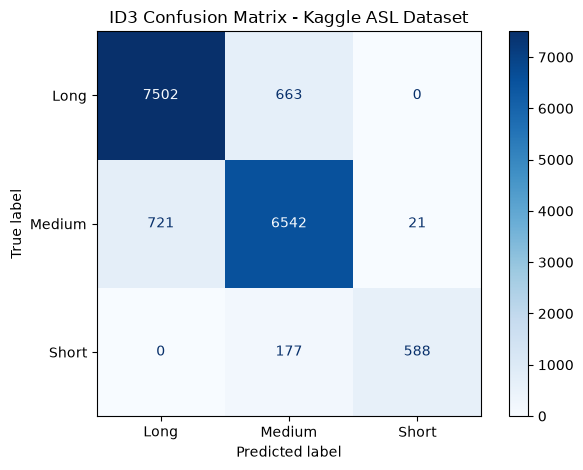

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

# Predict classes for untouched test data
test_predictions = best_model.predict(X_test_processed)

# Calculate final evaluation scores
test_accuracy = accuracy_score(y_test, test_predictions)
test_precision = precision_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
test_recall = recall_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)
test_f1 = f1_score(
    y_test,
    test_predictions,
    average="macro",
    zero_division=0
)

print("Final Test Results")
print("------------------")
print("Accuracy:", round(test_accuracy, 4))
print("Macro Precision:", round(test_precision, 4))
print("Macro Recall:", round(test_recall, 4))
print("Macro F1 Score:", round(test_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        zero_division=0
    )
)

# Display confusion matrix
class_names = best_model.classes_

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=class_names,
    display_labels=class_names,
    cmap="Blues"
)

plt.title("ID3 Confusion Matrix - Kaggle ASL Dataset")
plt.tight_layout()
plt.show()

,Feature,Importance
0,english_word_count,0.970142
1,punctuation_count,0.011750
2,average_word_length,0.007941
3,english_character_count,0.006255
4,digit_count,0.003197
5,question_mark_count,0.000715


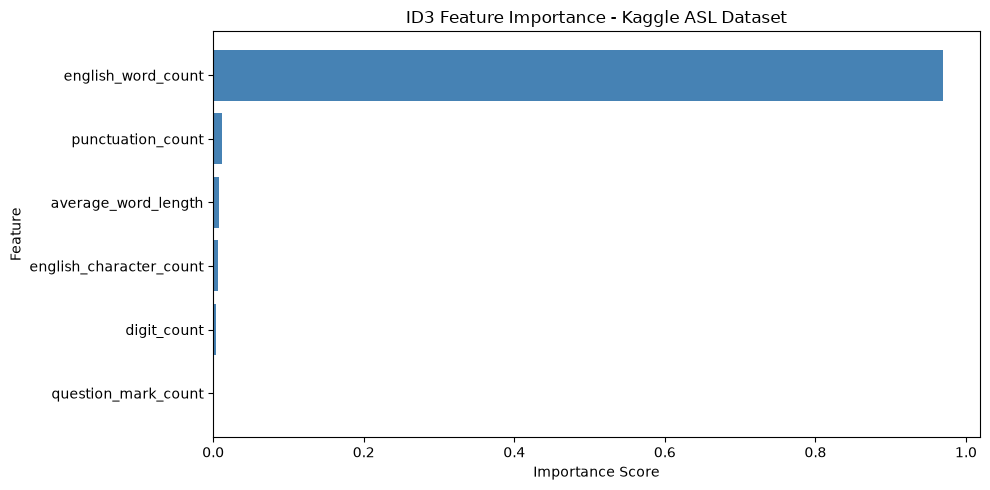

In [15]:
# Get feature importance from the trained ID3 model
feature_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": best_model.feature_importances_
})

# Sort features from highest to lowest importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 5))

plt.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color="steelblue"
)

plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("ID3 Feature Importance - Kaggle ASL Dataset")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [16]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Create a large figure for the complete decision tree
plt.figure(figsize=(50, 25))

plot_tree(
    best_model,
    feature_names=feature_columns,
    class_names=[str(name) for name in best_model.classes_],
    filled=True,
    rounded=True,
    fontsize=5
)

plt.title("Complete ID3 Decision Tree - Kaggle ASL Dataset", fontsize=20)
plt.tight_layout()

# Save the complete tree as a high-quality image
tree_image_path = (
    project_path
    / "results"
    / "kaggle_asl_full_id3_tree.png"
)

tree_image_path.parent.mkdir(parents=True, exist_ok=True)

plt.savefig(
    tree_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Full decision tree saved at:")
print(tree_image_path)

NameError: name 'project_path' is not defined

Error in callback <function flush_figures at 0x000002B348A6FF60> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

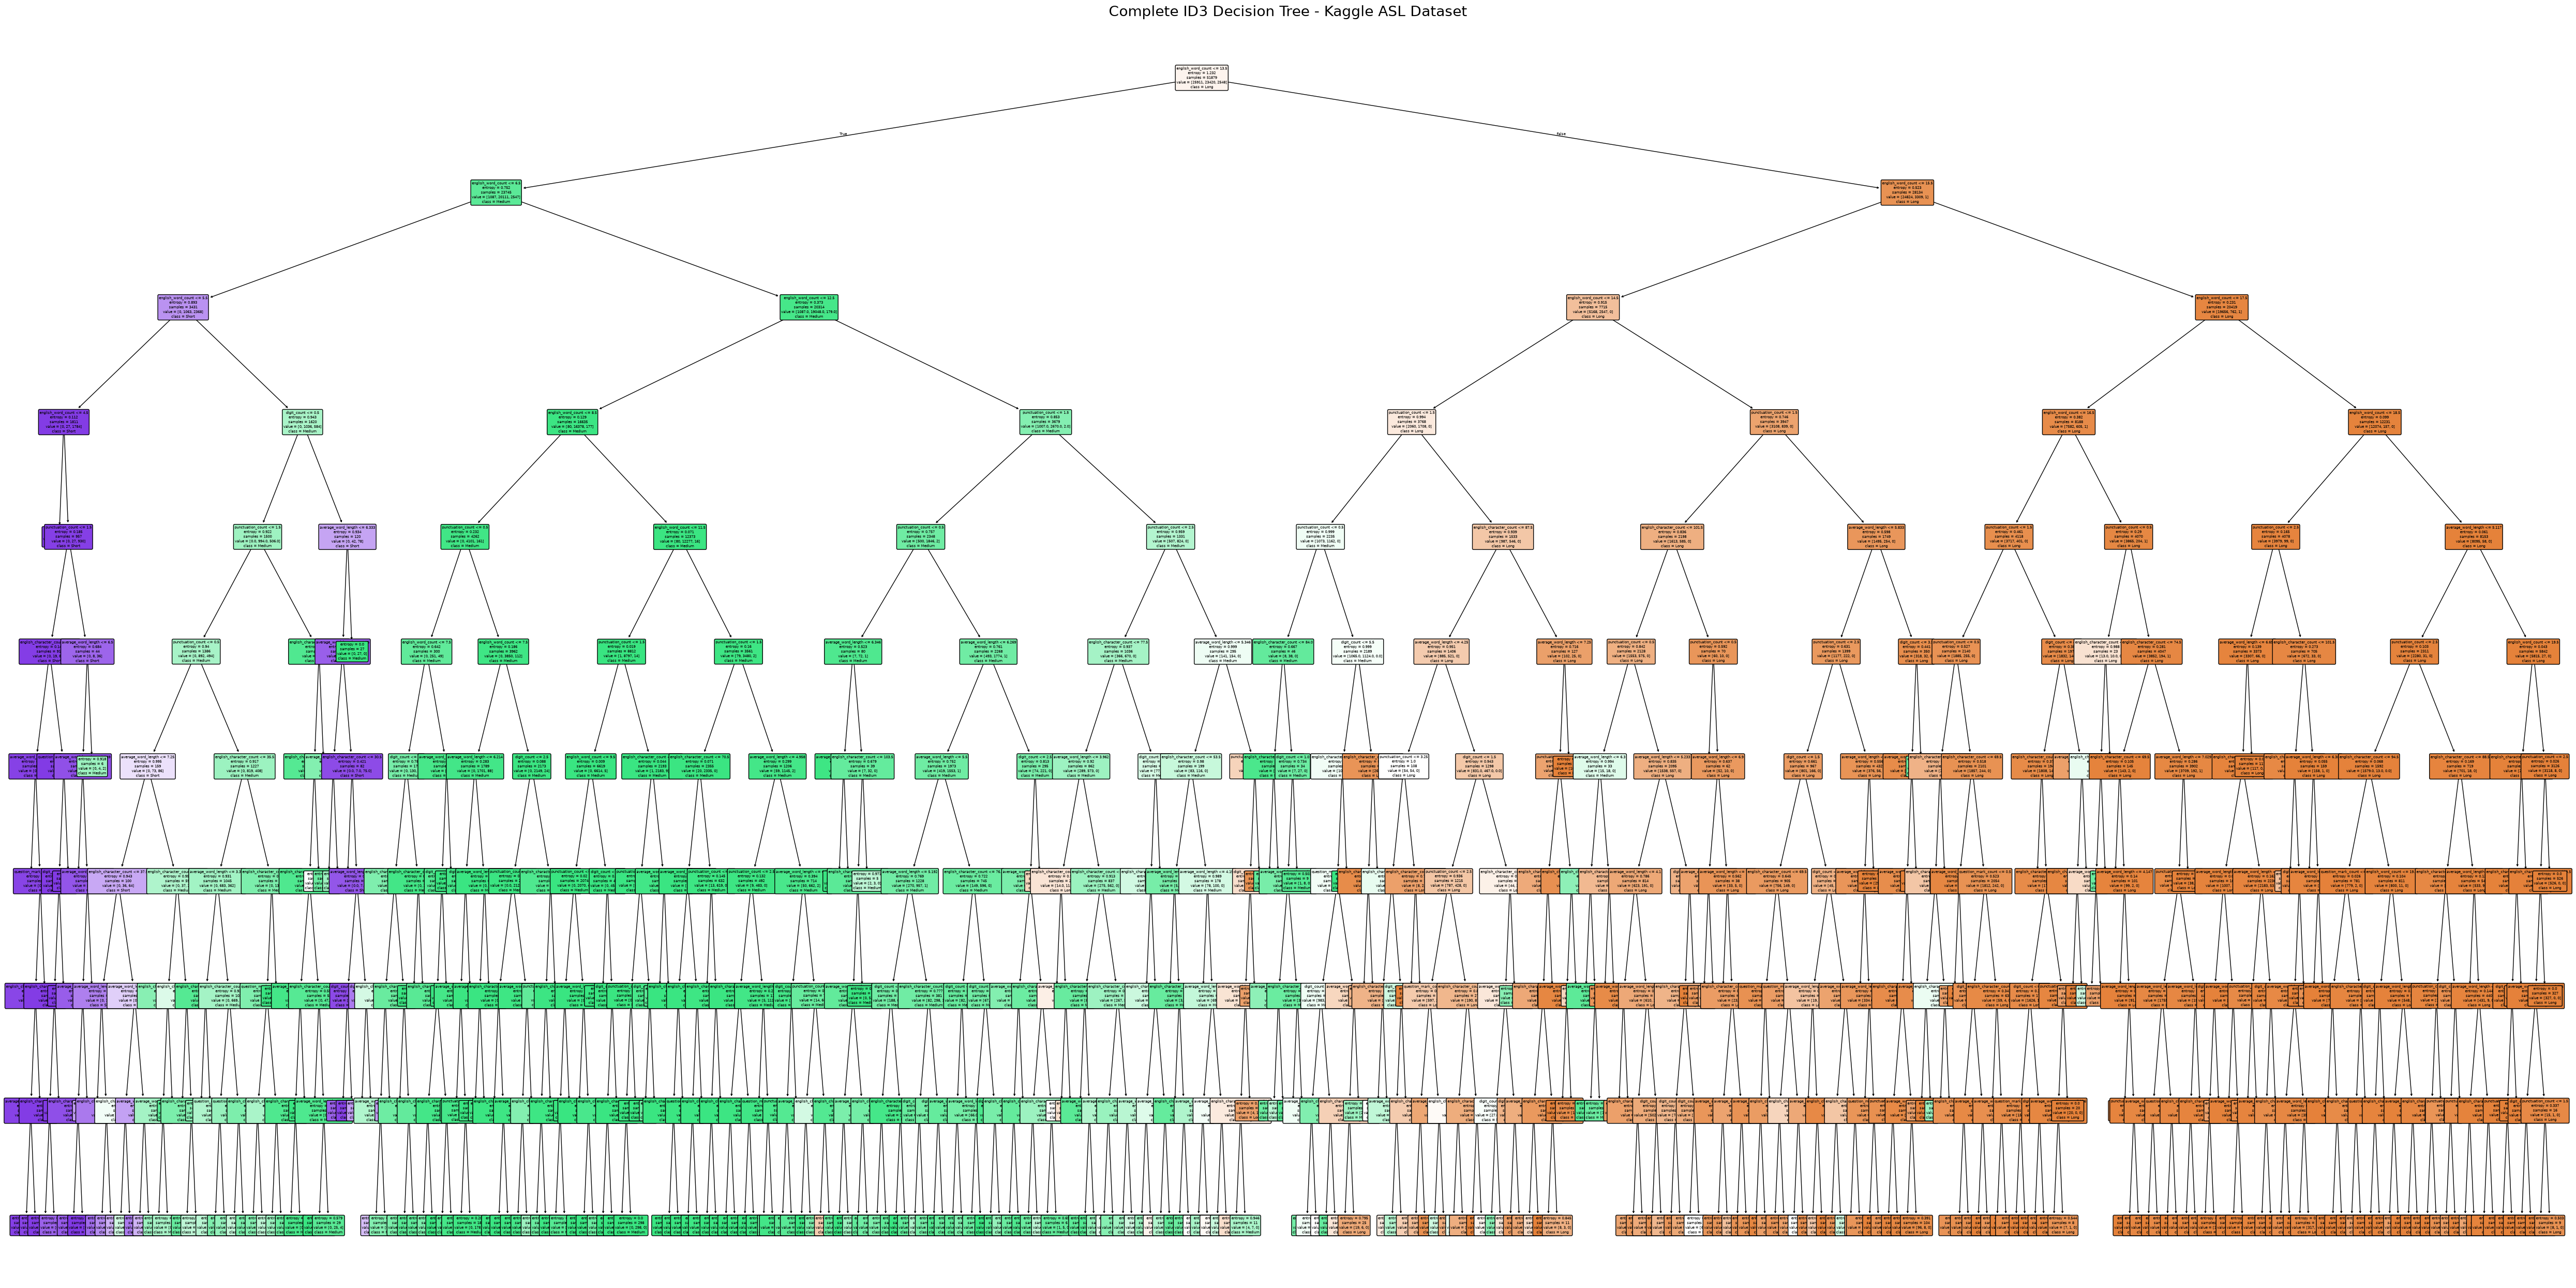

Full decision tree saved successfully:
c:\Users\HP\OneDrive\Documents\NeuraSign\results\kaggle_asl_full_id3_tree.png


In [17]:
from pathlib import Path
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# NeuraSign project folder
project_path = Path.cwd().parent

# Results folder
results_folder = project_path / "results"
results_folder.mkdir(parents=True, exist_ok=True)

# Complete tree image path
tree_image_path = results_folder / "kaggle_asl_full_id3_tree.png"

# Create complete ID3 decision tree
plt.figure(figsize=(50, 25))

plot_tree(
    best_model,
    feature_names=feature_columns,
    class_names=[str(name) for name in best_model.classes_],
    filled=True,
    rounded=True,
    fontsize=5
)

plt.title(
    "Complete ID3 Decision Tree - Kaggle ASL Dataset",
    fontsize=20
)

plt.tight_layout()

# Save high-resolution image
plt.savefig(
    tree_image_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Full decision tree saved successfully:")
print(tree_image_path)

In [18]:
import joblib
import json
from pathlib import Path

# Create folders
models_folder = project_path / "models"
results_folder = project_path / "results"

models_folder.mkdir(parents=True, exist_ok=True)
results_folder.mkdir(parents=True, exist_ok=True)

# File paths
model_path = models_folder / "kaggle_asl_id3_model.joblib"
results_path = results_folder / "kaggle_asl_id3_test_results.json"
validation_path = results_folder / "kaggle_asl_validation_results.csv"
importance_path = results_folder / "kaggle_asl_feature_importance.csv"

# Save trained ID3 model
joblib.dump(best_model, model_path)

# Save validation results
results_df.to_csv(
    validation_path,
    index=False
)

# Save feature importance
feature_importance_df.to_csv(
    importance_path,
    index=False
)

# Prepare final test results
final_results = {
    "dataset": "Kaggle ASL English-Gloss Parallel Dataset",
    "algorithm": "ID3 Decision Tree",
    "criterion": "entropy",
    "best_max_depth": best_parameters["max_depth"],
    "best_min_samples_leaf": best_parameters["min_samples_leaf"],
    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),
    "training_records": int(len(y_train)),
    "validation_records": int(len(y_val)),
    "test_records": int(len(y_test)),
    "features": feature_columns
}

# Save final results as JSON
with open(results_path, "w", encoding="utf-8") as file:
    json.dump(final_results, file, indent=4)

print("All files saved successfully:\n")
print("Model:", model_path)
print("Test results:", results_path)
print("Validation results:", validation_path)
print("Feature importance:", importance_path)

All files saved successfully:

Model: c:\Users\HP\OneDrive\Documents\NeuraSign\models\kaggle_asl_id3_model.joblib
Test results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\kaggle_asl_id3_test_results.json
Validation results: c:\Users\HP\OneDrive\Documents\NeuraSign\results\kaggle_asl_validation_results.csv
Feature importance: c:\Users\HP\OneDrive\Documents\NeuraSign\results\kaggle_asl_feature_importance.csv


In [19]:
# Create processed dataset folder
processed_folder = (
    project_path
    / "data"
    / "processed"
    / "kaggle_asl"
)

processed_folder.mkdir(parents=True, exist_ok=True)

# Output file paths
clean_data_path = processed_folder / "kaggle_asl_clean.csv"
model_data_path = processed_folder / "kaggle_asl_model_ready.csv"

# Save cleaned English-gloss pairs
clean_df.to_csv(
    clean_data_path,
    index=False,
    encoding="utf-8"
)

# Save feature-engineered dataset
model_df.to_csv(
    model_data_path,
    index=False,
    encoding="utf-8"
)

print("Processed datasets saved successfully:\n")
print("Clean dataset:", clean_data_path)
print("Model-ready dataset:", model_data_path)

print("\nSaved records:")
print("Clean dataset:", len(clean_df))
print("Model-ready dataset:", len(model_df))

Processed datasets saved successfully:

Clean dataset: c:\Users\HP\OneDrive\Documents\NeuraSign\data\processed\kaggle_asl\kaggle_asl_clean.csv
Model-ready dataset: c:\Users\HP\OneDrive\Documents\NeuraSign\data\processed\kaggle_asl\kaggle_asl_model_ready.csv

Saved records:
Clean dataset: 81065
Model-ready dataset: 81065
